## Convolutional Neural Networks (CNNs)

# Introduction

A Convolutional Neural Network (CNN) is a type of artificial neural network that is mainly designed for working with a grid-like structure such as images. It is one of the most important models in deep learning for image analysis. CNNs are used because images contain a large amount of information, and ordinary neural networks do not handle this information efficiently.

An image is made up of many small units called pixels. Each pixel has a value. In a grayscale image, each pixel has just one value that shows how dark or bright it is. In a color image, each pixel usually has three values, representing red, green, and blue. When all these pixel values are arranged together, they form a matrix or grid. Because of this grid structure, images are different from ordinary numerical data, and they need a special kind of network that can understand patterns in space. CNNs were developed for this purpose.

A CNN is able to learn useful visual patterns directly from images. It can learn simple patterns such as edges and corners, and it can also learn more complex patterns such as shapes, textures, leaves, faces, fruits, roads, or other objects. This makes CNNs very useful in many areas such as image classification, object detection, face recognition, medical image analysis, biometric systems, autonomous driving, and agricultural image processing.

In a fully connected neural network, every input value is connected to every neuron in the next layer. This may work well for small numerical datasets, but it becomes very difficult when the input is a large image.
Consider an image of size **100×100×3**. This means the image has **100 rows**, **100 columns**, and **3 color channels**. The total number of input values is:

$$
100 \times 100 \times 3 = 30,000
$$

If this image is given to a traditional neural network with only **1,000 neurons** in the next layer, the number of weights needed will be:

$$
30,000 \times 1,000 = 30,000,000
$$

This means the network must learn **30 million weights** in just one layer. This is extremely large. It requires a lot of memory, a lot of computation time, and a very large amount of training data. It also increases the chance of **overfitting**, which means the model may memorize the training images instead of learning general patterns that can work on new images.

Also, traditional neural network does not naturally preserve the spatial arrangement of pixels. In an image, the position of a feature matters. For example, nearby pixels often form important structures such as edges, corners, or textures. If we flatten the whole image into a long vector before giving it to a traditional neural network, much of this important spatial information is lost or weakened. The network no longer sees the image as a two-dimensional structure. Instead, it sees only a long list of numbers.

CNNs solve these problems in a more intelligent way. They do not connect every pixel to every neuron in the next layer. Instead, they examine the image in small parts at a time. They use small filters, also called kernels, to move across the image and detect local patterns. CNNs are much better suited for image data than ordinary neural networks. They are able to learn useful features automatically, without the need for manual feature extraction. In older image-processing systems, a human expert often had to design features by hand, such as edge detectors, texture measures, or shape descriptors. In CNNs, the network learns these features by itself during training.

A simple way to think about CNNs is this: instead of trying to understand the whole image at once, the CNN first looks for small simple patterns. Then, as the image passes through deeper layers, the network combines those simple patterns into more meaningful shapes and objects. For example, in the first layers it may detect edges. In the middle layers it may detect parts of objects. In the deeper layers it may recognize complete objects such as a face, a leaf, a fruit, or a vehicle.

## The Basic Idea of CNN

The basic idea of a Convolutional Neural Network is that it does not try to understand the entire image in one step. Instead, it studies the image gradually by examining small parts of it at a time. This is done with a small matrix called a filter or kernel. The kernel moves across the image from one position to another and checks for useful patterns in each small region.

At every position, the kernel performs a simple mathematical operation with the pixel values in that region and produces a number. As it continues to move across the image, it creates a new map called a feature map. This feature map shows where a particular pattern appears in the image. For example, one kernel may respond strongly to vertical edges, another may detect horizontal edges, and another may detect texture or curves.

In the early layers, the CNN learns very simple and basic features such as edges, lines, corners, and small texture patterns. These are the building blocks of an image. In the middle layers, the network begins to combine these simple features into more meaningful parts, such as shapes, contours, or object parts like eyes, leaves, or fruit boundaries. In the deeper layers, the CNN combines these learned parts into full and more complex objects, such as a face, a leaf, a fruit, a vehicle, or another recognizable item in the image.

## The Main Building Blocks of CNN

A Convolutional Neural Network is made up of several layers, and each layer performs a specific task in helping the network understand the image. These layers work together step by step. The first layer receives the image, the middle layers extract important features from it, and the final layers use those features to make a prediction. In this way, the CNN gradually changes the raw image into useful information that can be used for classification or detection.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving cnn_buildup.png to cnn_buildup.png


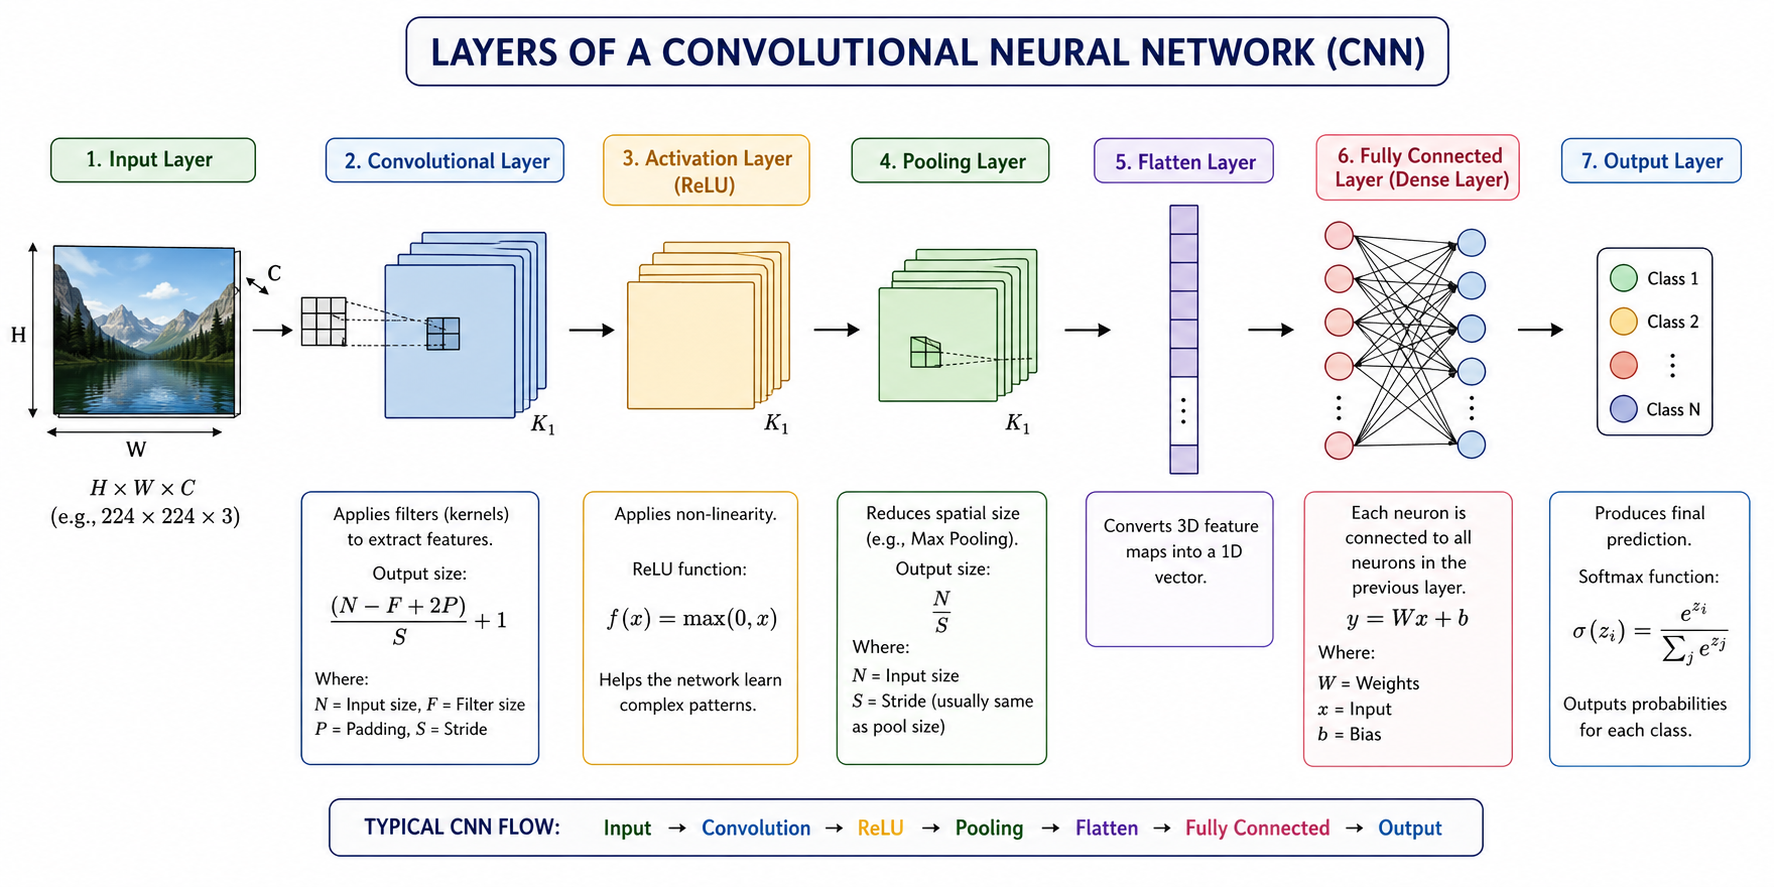

In [2]:
from IPython.display import Image, display

display(Image('cnn_buildup.png'))

## The Input layer

The input layer is the first layer of the CNN. It is the layer where the original image is given to the network. At this stage, the image has not yet been analyzed. It is simply represented as numerical pixel values arranged in rows, columns, and sometimes channels.

For a grayscale image, there is only one channel because each pixel contains only one intensity value. For example, an image of size 28×28×1 means the image has 28 rows, 28 columns, and 1 channel.

For an RGB image, there are three channels because each pixel is made up of red, green, and blue values. For example, an image of size 224×224×3 means the image has 224 rows, 224 columns, and 3 color channels.

The input layer is important because it determines the size and format of the data that will enter the network. All the later layers depend on this input structure. In simple terms, the input layer is the starting point of the CNN, where the network receives the image exactly as data before beginning feature extraction.

## Convolutional Layer

The convolutional layer is the core layer of a CNN because it is the layer that begins to extract useful features from the image. Instead of treating the whole image as one large block of numbers, this layer looks at small parts of the image one after another. In this way, it can detect local patterns that are important for understanding the image.

This layer uses a small matrix called a filter or kernel. The kernel slides across the image from left to right and from top to bottom. At each position, it covers a small region of the image and performs element-wise multiplication between its values and the pixel values in that region. After this multiplication, all the results are added together to produce one output value. This process is called convolution.

For example, suppose we use a **3 × 3 filter**:

$$
\begin{bmatrix}
1 & 0 & -1 \\
1 & 0 & -1 \\
1 & 0 & -1
\end{bmatrix}
$$

This filter can help detect **vertical edges** because it responds strongly when there is a sharp change in pixel values from one side of a region to the other. If such a vertical pattern is present in the image, the filter will produce a large response.

As the filter moves across the entire image, it produces many output values. These values are arranged into a new matrix called a feature map. The feature map shows where that particular feature appears in the image. If the network uses one filter, it produces one feature map. If it uses 32 different filters, then it produces 32 feature maps, with each one focusing on a different type of feature such as edges, curves, textures, or simple shapes.

Important Terms in Convolutional Layers

Some important terms related to the convolutional layer should be understood clearly:

1. **Kernel or Filter:**  
   This is the small matrix used to search for specific features in the image.

2. **Stride:**  
   This is the number of steps the filter moves each time. A stride of 1 means the filter moves one pixel at a time. A stride of 2 means it jumps two pixels at a time. Larger stride reduces the output size  

3. **Padding:**  
   This means adding zeros around the border of the image before applying the filter.  
   Padding helps preserve information near the edges of the image and can also help control the size of the output feature map.


In simple terms, the convolutional layer acts like a **feature detector**. It scans the image carefully, identifies useful patterns, and passes this information to the next layers. This is why it is considered the most important layer in a CNN.

A demonstration of how a filter/kernel moves across the image and performs element-wise multiplication, and then sums the result.

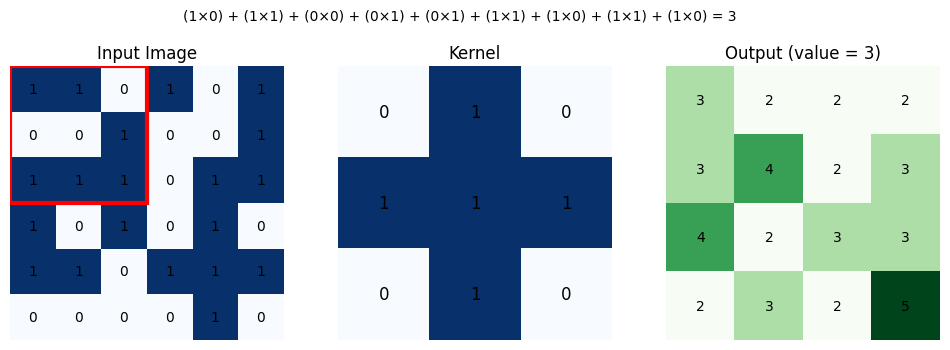

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from IPython.display import HTML

image = np.array([
    [1, 1, 0, 1, 0, 1],
    [0, 0, 1, 0, 0, 1],
    [1, 1, 1, 0, 1, 1],
    [1, 0, 1, 0, 1, 0],
    [1, 1, 0, 1, 1, 1],
    [0, 0, 0, 0, 1, 0]
])

kernel = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
])

fig, axes = plt.subplots(1, 3, figsize=(12,4))

h, w = image.shape
output = np.zeros((h-2, w-2))

steps = []
for i in range(h-2):
    for j in range(w-2):
        region = image[i:i+3, j:j+3]
        value = np.sum(region * kernel)
        steps.append((i, j, region, value))


def draw_matrix(ax, matrix, title):
    ax.imshow(matrix, cmap='Blues')
    for r in range(matrix.shape[0]):
        for c in range(matrix.shape[1]):
            ax.text(c, r, str(matrix[r, c]),
                    ha='center', va='center', fontsize=12, color='black')
    ax.set_title(title)
    ax.axis('off')


def update(frame):
    for ax in axes:
        ax.clear()

    i, j, region, value = steps[frame]

    # LEFT: full image
    axes[0].imshow(image, cmap='Blues')
    for r in range(h):
        for c in range(w):
            axes[0].text(c, r, str(image[r,c]),
                         ha='center', va='center')

    # highlight sliding window
    rect = Rectangle((j-0.5, i-0.5), 3, 3,
                     linewidth=3, edgecolor='red', facecolor='none')
    axes[0].add_patch(rect)
    axes[0].set_title("Input Image")
    axes[0].axis('off')

    # MIDDLE: kernel
    draw_matrix(axes[1], kernel, "Kernel")

    # RIGHT: output
    output[i, j] = value
    axes[2].imshow(output, cmap='Greens')

    for r in range(output.shape[0]):
        for c in range(output.shape[1]):
            axes[2].text(c, r, str(int(output[r,c])),
                         ha='center', va='center')

    axes[2].set_title(f"Output (value = {int(value)})")
    axes[2].axis('off')

    # Show equation (like your image)
    equation = ""
    terms = []
    for r in range(3):
        for c in range(3):
            terms.append(f"({region[r,c]}×{kernel[r,c]})")
    equation = " + ".join(terms) + f" = {int(value)}"

    plt.suptitle(equation, fontsize=10)


ani = animation.FuncAnimation(
    fig, update, frames=len(steps), interval=1200
)

HTML(ani.to_jshtml())

Another Example

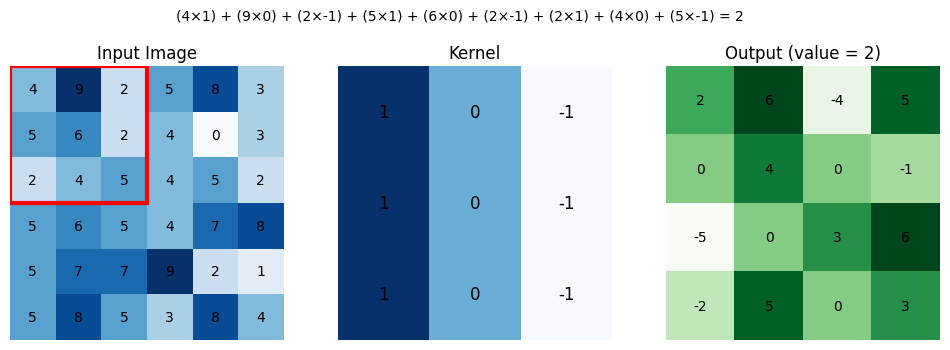

In [2]:
import numpy as np

image = np.array([
    [4, 9, 2, 5, 8, 3],
    [5, 6, 2, 4, 0, 3],
    [2, 4, 5, 4, 5, 2],
    [5, 6, 5, 4, 7, 8],
    [5, 7, 7, 9, 2, 1],
    [5, 8, 5, 3, 8, 4]
])

kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from IPython.display import HTML

fig, axes = plt.subplots(1, 3, figsize=(12,4))

h, w = image.shape
output = np.zeros((h-2, w-2))

steps = []
for i in range(h-2):
    for j in range(w-2):
        region = image[i:i+3, j:j+3]
        value = np.sum(region * kernel)
        steps.append((i, j, region, value))


def draw_matrix(ax, matrix, title):
    ax.imshow(matrix, cmap='Blues')
    for r in range(matrix.shape[0]):
        for c in range(matrix.shape[1]):
            ax.text(c, r, str(matrix[r, c]),
                    ha='center', va='center', fontsize=12, color='black')
    ax.set_title(title)
    ax.axis('off')


def update(frame):
    for ax in axes:
        ax.clear()

    i, j, region, value = steps[frame]

    # LEFT: full image
    axes[0].imshow(image, cmap='Blues')
    for r in range(h):
        for c in range(w):
            axes[0].text(c, r, str(image[r,c]),
                         ha='center', va='center')

    # highlight sliding window
    rect = Rectangle((j-0.5, i-0.5), 3, 3,
                     linewidth=3, edgecolor='red', facecolor='none')
    axes[0].add_patch(rect)
    axes[0].set_title("Input Image")
    axes[0].axis('off')

    # MIDDLE: kernel
    draw_matrix(axes[1], kernel, "Kernel")

    # RIGHT: output
    output[i, j] = value
    axes[2].imshow(output, cmap='Greens')

    for r in range(output.shape[0]):
        for c in range(output.shape[1]):
            axes[2].text(c, r, str(int(output[r,c])),
                         ha='center', va='center')

    axes[2].set_title(f"Output (value = {int(value)})")
    axes[2].axis('off')

    # Show equation (like your image)
    equation = ""
    terms = []
    for r in range(3):
        for c in range(3):
            terms.append(f"({region[r,c]}×{kernel[r,c]})")
    equation = " + ".join(terms) + f" = {int(value)}"

    plt.suptitle(equation, fontsize=10)


ani = animation.FuncAnimation(
    fig, update, frames=len(steps), interval=1200
)

HTML(ani.to_jshtml())

Convolutional layers apply filters (kernels) to extract features such as edges, textures, and patterns. The output size is computed as:

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$\frac{N - F + 2P}{S} + 1$

Where:

&nbsp;&nbsp;&nbsp;&nbsp;$N$ = Input size  
&nbsp;&nbsp;&nbsp;&nbsp;$F$ = Filter size  
&nbsp;&nbsp;&nbsp;&nbsp;$P$ = Padding  
&nbsp;&nbsp;&nbsp;&nbsp;$S$ = Stride  

In the above two demonstration, $ N = 6, F = 3, P = 0, S = 1 $. We can therefore compute the Output size as:

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$\frac{N - F + 2P}{S} + 1 = \frac{6 - 3 + 2(0)}{1} + 1 = 4$

Suppose Padding is introduced and stride becomes S = 2 as shown below, we can compute the output as: $\frac{6 - 3 + 2(1)}{2} + 1 = 3$

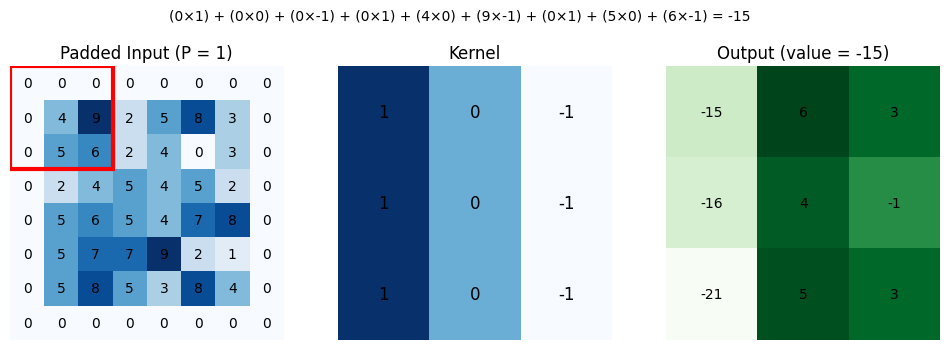

In [3]:
# Stride, S = 2, Padding, P = 1

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from IPython.display import HTML

# --------------------------------------------------
# Input image
# --------------------------------------------------
image = np.array([
    [4, 9, 2, 5, 8, 3],
    [5, 6, 2, 4, 0, 3],
    [2, 4, 5, 4, 5, 2],
    [5, 6, 5, 4, 7, 8],
    [5, 7, 7, 9, 2, 1],
    [5, 8, 5, 3, 8, 4]
])

kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

# --------------------------------------------------
# Parameters
# --------------------------------------------------
stride = 2
filter_size = 3
padding = 1

# --------------------------------------------------
# Apply padding
# --------------------------------------------------
padded_image = np.pad(
    image,
    pad_width=padding,
    mode='constant',
    constant_values=0
)

h, w = padded_image.shape

# --------------------------------------------------
# Output size (WITH padding)
# --------------------------------------------------
output_h = (h - filter_size) // stride + 1
output_w = (w - filter_size) // stride + 1
output = np.zeros((output_h, output_w))

# --------------------------------------------------
# Prepare animation
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# --------------------------------------------------
# Generate steps
# --------------------------------------------------
steps = []
out_i = 0

for i in range(0, h - filter_size + 1, stride):
    out_j = 0
    for j in range(0, w - filter_size + 1, stride):

        region = padded_image[i:i+filter_size, j:j+filter_size]
        value = np.sum(region * kernel)

        steps.append((i, j, out_i, out_j, region, value))
        out_j += 1

    out_i += 1


# --------------------------------------------------
# Helper function
# --------------------------------------------------
def draw_matrix(ax, matrix, title):
    ax.imshow(matrix, cmap='Blues')

    for r in range(matrix.shape[0]):
        for c in range(matrix.shape[1]):
            ax.text(c, r, str(matrix[r, c]),
                    ha='center', va='center', fontsize=12)

    ax.set_title(title)
    ax.axis('off')


# --------------------------------------------------
# Animation update
# --------------------------------------------------
def update(frame):
    for ax in axes:
        ax.clear()

    i, j, oi, oj, region, value = steps[frame]

    # LEFT: padded image
    axes[0].imshow(padded_image, cmap='Blues')

    for r in range(h):
        for c in range(w):
            axes[0].text(c, r, str(padded_image[r, c]),
                         ha='center', va='center')

    # Highlight window
    rect = Rectangle(
        (j - 0.5, i - 0.5),
        filter_size,
        filter_size,
        linewidth=3,
        edgecolor='red',
        facecolor='none'
    )
    axes[0].add_patch(rect)

    axes[0].set_title("Padded Input (P = 1)")
    axes[0].axis('off')

    # MIDDLE: kernel
    draw_matrix(axes[1], kernel, "Kernel")

    # RIGHT: output
    output[oi, oj] = value
    axes[2].imshow(output, cmap='Greens')

    for r in range(output.shape[0]):
        for c in range(output.shape[1]):
            axes[2].text(c, r, str(int(output[r, c])),
                         ha='center', va='center')

    axes[2].set_title(f"Output (value = {int(value)})")
    axes[2].axis('off')

    # Equation
    terms = []
    for r in range(filter_size):
        for c in range(filter_size):
            terms.append(f"({region[r,c]}×{kernel[r,c]})")

    equation = " + ".join(terms) + f" = {int(value)}"
    plt.suptitle(equation, fontsize=10)


# --------------------------------------------------
# Run animation
# --------------------------------------------------
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(steps),
    interval=1500,
    repeat=False
)

HTML(ani.to_jshtml())

Suppose the slide $S = (2, 1)$ and padding $P = 0$, the output for a 2D convolution can be obtained by:

$
\text{Output Height} = \left\lfloor \frac{H - F_h + 2P_h}{S_h} \right\rfloor + 1
$

$
\text{Output Width} = \left\lfloor \frac{W - F_w + 2P_w}{S_w} \right\rfloor + 1
$

Where;

\begin{aligned}
H, W & = \text{Input height and width} \\
F_h, F_w & = \text{Filter size (height, width)} \\
P_h, P_w & = \text{Padding} \\
S_h, S_w & = \text{Stride}
\end{aligned}

Given that $S = (2,1),$ this means that $S_h = 2, S_w = 1$.

The convolutional layer output size will be:

$
\text{Output Height} = \left\lfloor \frac{H - F_h + 2P_h}{S_h} \right\rfloor + 1 = \left\lfloor \frac{6 - 3 + 2(0)}{2} \right\rfloor + 1 = \left\lfloor \frac{3}{2} \right\rfloor + 1 = 2
$

$
\text{Output Width} = \left\lfloor \frac{W - F_w + 2P_w}{S_w} \right\rfloor + 1 = \left\lfloor \frac{6 - 3 + 2(0)}{1} \right\rfloor + 1 = \left\lfloor 3 \right\rfloor + 1 = 4
$

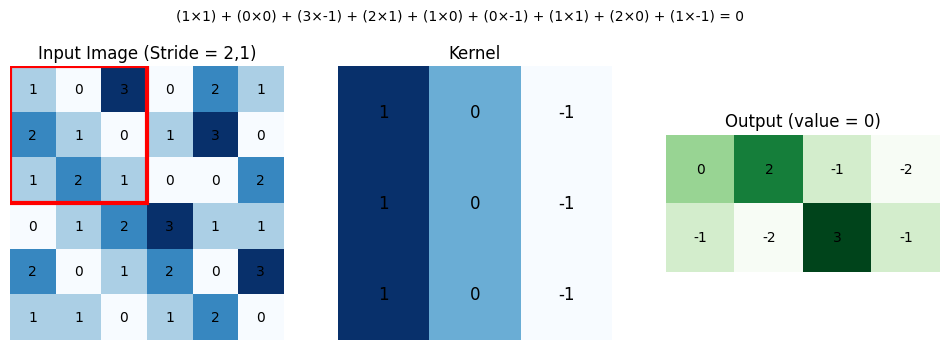

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from IPython.display import HTML

# --------------------------------------------------
# Input image
# --------------------------------------------------
image = np.array([
    [1, 0, 3, 0, 2, 1],
    [2, 1, 0, 1, 3, 0],
    [1, 2, 1, 0, 0, 2],
    [0, 1, 2, 3, 1, 1],
    [2, 0, 1, 2, 0, 3],
    [1, 1, 0, 1, 2, 0]
])

kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

# --------------------------------------------------
# Parameters
# --------------------------------------------------
stride_r = 2   # vertical stride
stride_c = 1   # horizontal stride
filter_size = 3

h, w = image.shape

# --------------------------------------------------
# Output size (stride 2,1)
# --------------------------------------------------
output_h = (h - filter_size) // stride_r + 1
output_w = (w - filter_size) // stride_c + 1
output = np.zeros((output_h, output_w))

# --------------------------------------------------
# Prepare animation
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# --------------------------------------------------
# Generate steps
# --------------------------------------------------
steps = []
out_i = 0

for i in range(0, h - filter_size + 1, stride_r):
    out_j = 0
    for j in range(0, w - filter_size + 1, stride_c):

        region = image[i:i+filter_size, j:j+filter_size]
        value = np.sum(region * kernel)

        steps.append((i, j, out_i, out_j, region, value))
        out_j += 1

    out_i += 1


# --------------------------------------------------
# Helper function
# --------------------------------------------------
def draw_matrix(ax, matrix, title):
    ax.imshow(matrix, cmap='Blues')

    for r in range(matrix.shape[0]):
        for c in range(matrix.shape[1]):
            ax.text(c, r, str(matrix[r, c]),
                    ha='center', va='center', fontsize=12)

    ax.set_title(title)
    ax.axis('off')


# --------------------------------------------------
# Animation update
# --------------------------------------------------
def update(frame):
    for ax in axes:
        ax.clear()

    i, j, oi, oj, region, value = steps[frame]

    # LEFT: input image
    axes[0].imshow(image, cmap='Blues')

    for r in range(h):
        for c in range(w):
            axes[0].text(c, r, str(image[r, c]),
                         ha='center', va='center')

    # Highlight sliding window
    rect = Rectangle(
        (j - 0.5, i - 0.5),
        filter_size,
        filter_size,
        linewidth=3,
        edgecolor='red',
        facecolor='none'
    )
    axes[0].add_patch(rect)

    axes[0].set_title("Input Image (Stride = 2,1)")
    axes[0].axis('off')

    # MIDDLE: kernel
    draw_matrix(axes[1], kernel, "Kernel")

    # RIGHT: output
    output[oi, oj] = value
    axes[2].imshow(output, cmap='Greens')

    for r in range(output.shape[0]):
        for c in range(output.shape[1]):
            axes[2].text(c, r, str(int(output[r, c])),
                         ha='center', va='center')

    axes[2].set_title(f"Output (value = {int(value)})")
    axes[2].axis('off')

    # Equation
    terms = []
    for r in range(filter_size):
        for c in range(filter_size):
            terms.append(f"({region[r,c]}×{kernel[r,c]})")

    equation = " + ".join(terms) + f" = {int(value)}"
    plt.suptitle(equation, fontsize=10)


# --------------------------------------------------
# Run animation
# --------------------------------------------------
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(steps),
    interval=1500,
    repeat=False
)

HTML(ani.to_jshtml())

### Multichannel CNN Convolution

In many practical CNN problems, the input image does not have just one channel. Instead, it may have multiple channels. For example, an RGB image has three channels: red, green, and blue. In this case, convolution is called multichannel convolution.

In multichannel convolution, the filter must have the same depth as the input. This means that if the input image has 3 channels, then each filter must also have 3 channels. So, a filter is no longer just 3×3; instead, it becomes 3×3×3 for an RGB image.

The convolution works as follows. The filter is placed on a small region of the input image. Since both the image and the filter have several channels, the multiplication is done separately on each channel. After that, all the results from all channels are added together to produce one single output value at that position.

So the process has three simple steps:

1. Multiply the filter values with the matching pixel values in each channel.
2. Sum the results inside each channel.
3. Add the sums from all channels together to get one final number.

This final number becomes one element in the feature map.

In [5]:
from google.colab import files
uploaded = files.upload()

Saving multichannel.jpg to multichannel.jpg


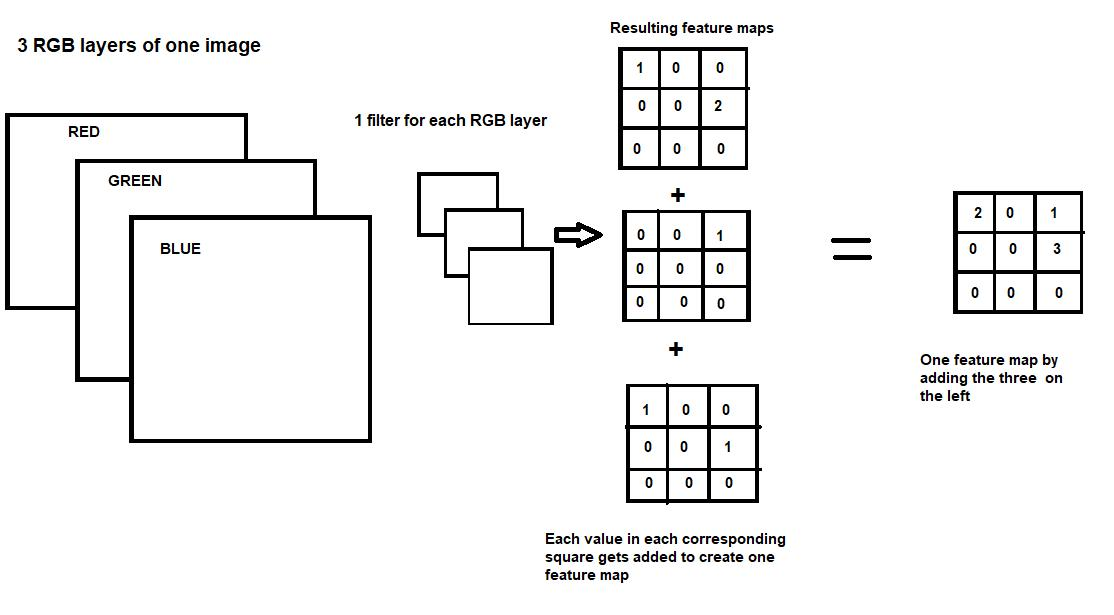

In [6]:
from IPython.display import Image, display

display(Image('multichannel.jpg'))

Multichannel convolution allows the CNN to use information from all channels at the same time. In an RGB image, this means the model does not look at red, green, and blue separately in isolation. Instead, it learns how color information across the channels combines to form useful patterns. This helps the CNN detect richer and more meaningful features.

Multichannel convolutional demo

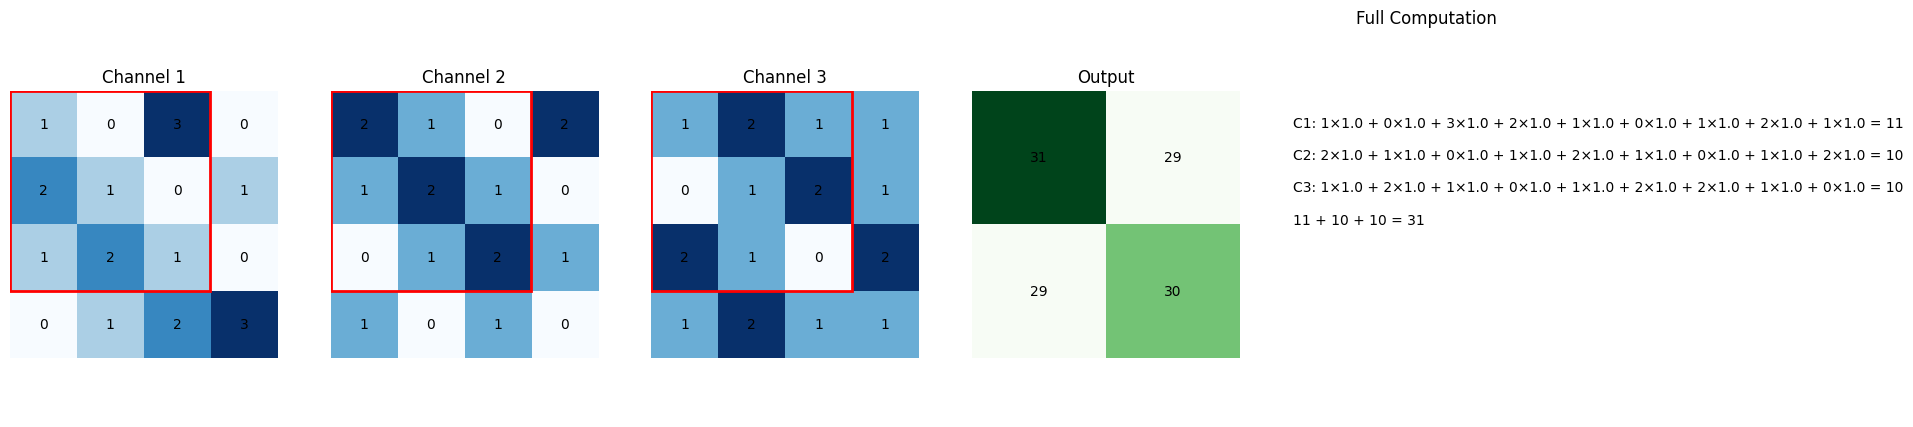

In [7]:
#%%
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from IPython.display import HTML

# --------------------------------------------------
# 3-Channel Input
# --------------------------------------------------
image = np.array([
    [[1,2,1], [0,1,2], [3,0,1], [0,2,1]],
    [[2,1,0], [1,2,1], [0,1,2], [1,0,1]],
    [[1,0,2], [2,1,1], [1,2,0], [0,1,2]],
    [[0,1,1], [1,0,2], [2,1,1], [3,0,1]]
])

# Kernel
kernel = np.ones((3,3,3))

# --------------------------------------------------
# Parameters
# --------------------------------------------------
stride = 1
filter_size = 3

h, w, c = image.shape

output_h = (h - filter_size) // stride + 1
output_w = (w - filter_size) // stride + 1
output = np.zeros((output_h, output_w))

# --------------------------------------------------
# Setup figure
# --------------------------------------------------
fig, axes = plt.subplots(1, 5, figsize=(20,5))

# --------------------------------------------------
# Generate steps
# --------------------------------------------------
steps = []
out_i = 0

for i in range(0, h - filter_size + 1, stride):
    out_j = 0
    for j in range(0, w - filter_size + 1, stride):

        channel_vals = []
        equations = []

        for ch in range(c):
            region = image[i:i+filter_size, j:j+filter_size, ch]
            k = kernel[:,:,ch]

            terms = []
            for r in range(filter_size):
                for col in range(filter_size):
                    terms.append(f"{region[r,col]}×{k[r,col]}")

            eq = " + ".join(terms)
            val = int(np.sum(region * k))

            equations.append(eq + f" = {val}")
            channel_vals.append(val)

        total = sum(channel_vals)

        steps.append((i, j, out_i, out_j, channel_vals, equations, total))
        out_j += 1

    out_i += 1


# --------------------------------------------------
# Animation update
# --------------------------------------------------
def update(frame):

    for ax in axes:
        ax.clear()

    i, j, oi, oj, ch_vals, equations, total = steps[frame]

    # Show channels
    for ch in range(c):
        axes[ch].imshow(image[:,:,ch], cmap='Blues')

        for r in range(h):
            for col in range(w):
                axes[ch].text(col, r, str(image[r, col, ch]),
                              ha='center', va='center')

        rect = Rectangle(
            (j-0.5, i-0.5),
            filter_size,
            filter_size,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        axes[ch].add_patch(rect)

        axes[ch].set_title(f"Channel {ch+1}")
        axes[ch].axis('off')

    # Output map
    output[oi, oj] = total
    axes[3].imshow(output, cmap='Greens')

    for r in range(output.shape[0]):
        for col in range(output.shape[1]):
            axes[3].text(col, r, str(int(output[r, col])),
                         ha='center', va='center')

    axes[3].set_title("Output")
    axes[3].axis('off')

    # FULL EQUATION DISPLAY
    text = ""
    for idx, eq in enumerate(equations):
        text += f"C{idx+1}: {eq}\n\n"

    text += " + ".join([str(v) for v in ch_vals])
    text += f" = {total}"

    axes[4].text(0, 0.5, text, fontsize=10)
    axes[4].set_title("Full Computation")
    axes[4].axis('off')


# --------------------------------------------------
# Animate
# --------------------------------------------------
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(steps),
    interval=2000,
    repeat=False
)

HTML(ani.to_jshtml())

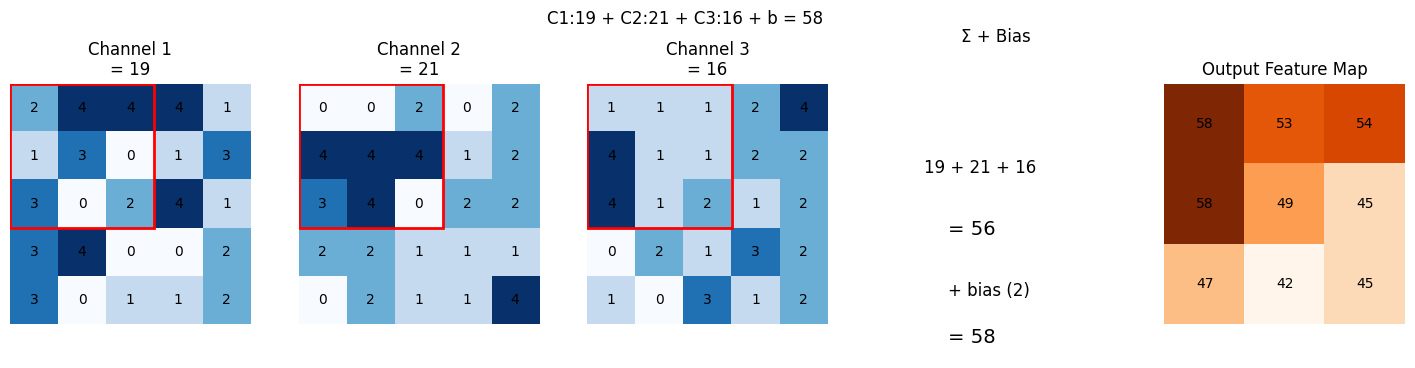

In [11]:
#%%
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from IPython.display import HTML

# --------------------------------------------------
# INPUT: 5x5x3 Feature Maps
# --------------------------------------------------
X = np.random.randint(0, 5, (5,5,3))

# Kernel: 3x3x3
F = np.ones((3,3,3))

bias = 2  # bias term

# --------------------------------------------------
# Parameters
# --------------------------------------------------
H, W, C = X.shape
F_size = 3
stride = 1

out_h = (H - F_size)//stride + 1
out_w = (W - F_size)//stride + 1
output = np.zeros((out_h, out_w))

# --------------------------------------------------
# Prepare steps
# --------------------------------------------------
steps = []

for i in range(out_h):
    for j in range(out_w):

        channel_vals = []

        for c in range(C):
            region = X[i:i+F_size, j:j+F_size, c]
            val = np.sum(region * F[:,:,c])
            channel_vals.append(val)

        total = sum(channel_vals)
        final = total + bias

        steps.append((i, j, channel_vals, total, final))


# --------------------------------------------------
# Plot setup
# --------------------------------------------------
fig, axes = plt.subplots(1, 5, figsize=(18,4))

titles = ["Channel 1", "Channel 2", "Channel 3",
          "Summation (Σ)", "Output"]

# --------------------------------------------------
# Animation function
# --------------------------------------------------
def update(frame):

    for ax in axes:
        ax.clear()

    i, j, ch_vals, total, final = steps[frame]

    # SHOW CHANNELS
    for c in range(3):
        axes[c].imshow(X[:,:,c], cmap='Blues')

        for r in range(H):
            for col in range(W):
                axes[c].text(col, r, str(X[r,col,c]),
                             ha='center', va='center')

        rect = Rectangle((j-0.5, i-0.5), 3, 3,
                         linewidth=2, edgecolor='red',
                         facecolor='none')
        axes[c].add_patch(rect)

        axes[c].set_title(f"{titles[c]}\n= {int(ch_vals[c])}")
        axes[c].axis('off')

    # SUMMATION
    axes[3].text(0.2, 0.6,
                 " + ".join(map(str, map(int, ch_vals))),
                 fontsize=12)

    axes[3].text(0.3, 0.4,
                 f"= {int(total)}",
                 fontsize=14)

    axes[3].text(0.3, 0.2,
                 f"+ bias ({bias})",
                 fontsize=12)

    axes[3].text(0.3, 0.05,
                 f"= {int(final)}",
                 fontsize=14)

    axes[3].set_title("Σ + Bias")
    axes[3].axis('off')

    # OUTPUT MAP
    output[i,j] = final
    axes[4].imshow(output, cmap='Oranges')

    for r in range(output.shape[0]):
        for col in range(output.shape[1]):
            axes[4].text(col, r, str(int(output[r,col])),
                         ha='center', va='center')

    axes[4].set_title("Output Feature Map")
    axes[4].axis('off')

    # TOP TITLE (like diagram)
    eq = " + ".join([f"C{idx+1}:{int(v)}" for idx, v in enumerate(ch_vals)])
    eq += f" + b = {int(final)}"

    plt.suptitle(eq, fontsize=12)


# --------------------------------------------------
# Run animation
# --------------------------------------------------
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(steps),
    interval=1500,
    repeat=False
)

HTML(ani.to_jshtml())

Even though the input has many channels, one filter still produces only one feature map. This is because the results from all channels are combined into a single output at each location.

If we use:

**$a).$** 1 filter, we get 1 feature map
**$b).$** 32 filters, we get 32 feature maps
**$c).$** 64 filters, we get 64 feature maps

So, the number of output feature maps depends on the number of filters, not on the number of input channels.

In [8]:
from google.colab import files
uploaded = files.upload()

Saving filters.jpg to filters.jpg


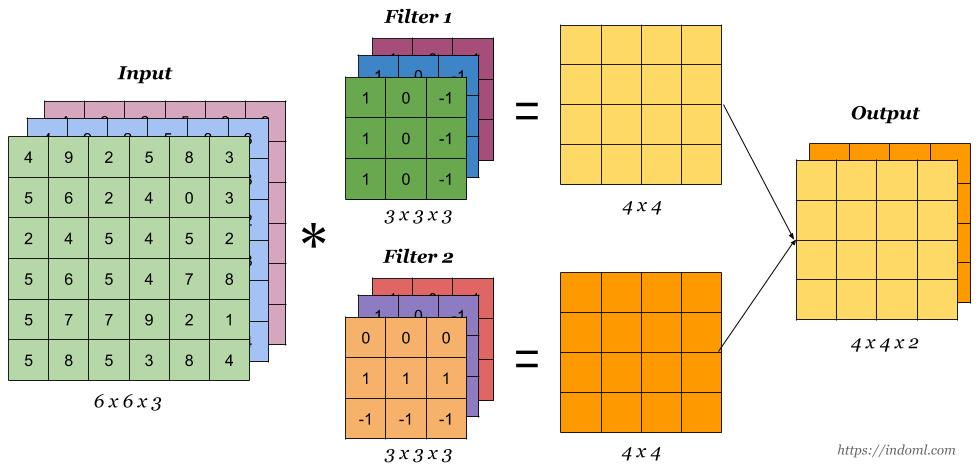

In [9]:
from IPython.display import Image, display

display(Image('filters.jpg'))

### TWO FILTERS ANIMATION DEMO

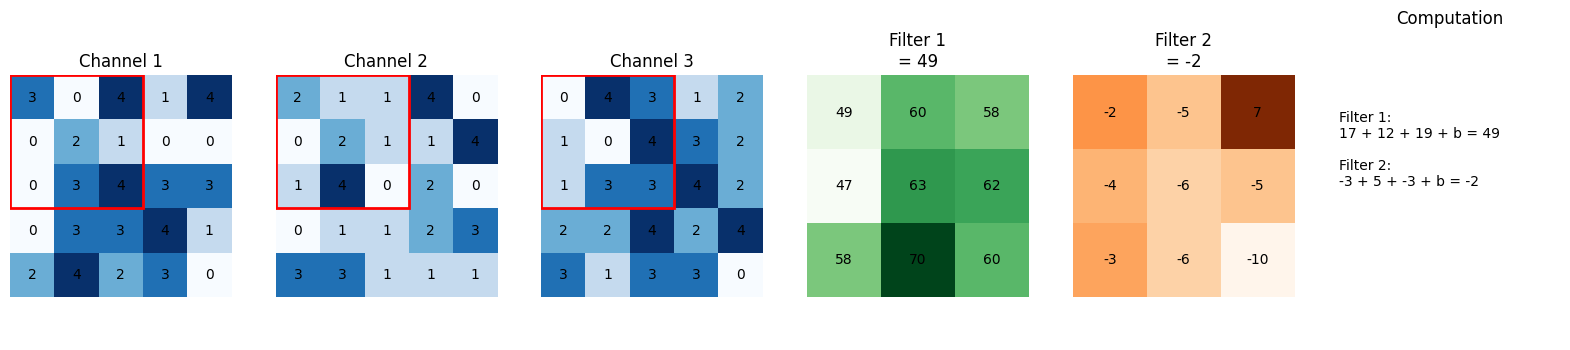

In [10]:
#%%
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from IPython.display import HTML

# --------------------------------------------------
# INPUT: 5x5x3 Feature Maps
# --------------------------------------------------
X = np.random.randint(0, 5, (5,5,3))

# --------------------------------------------------
# TWO DIFFERENT FILTERS (3x3x3)
# --------------------------------------------------
F1 = np.ones((3,3,3))              # Filter 1 (all ones)
F2 = np.random.randint(-1, 2, (3,3,3))  # Filter 2 (mixed weights)

bias1 = 1
bias2 = -1

filters = [(F1, bias1, "Filter 1"),
           (F2, bias2, "Filter 2")]

# --------------------------------------------------
# Parameters
# --------------------------------------------------
H, W, C = X.shape
F_size = 3
stride = 1

out_h = (H - F_size)//stride + 1
out_w = (W - F_size)//stride + 1

# Output maps (2 filters)
output1 = np.zeros((out_h, out_w))
output2 = np.zeros((out_h, out_w))

# --------------------------------------------------
# Prepare steps
# --------------------------------------------------
steps = []

for i in range(out_h):
    for j in range(out_w):

        results = []

        for (F, b, name) in filters:

            channel_vals = []

            for c in range(C):
                region = X[i:i+F_size, j:j+F_size, c]
                val = np.sum(region * F[:,:,c])
                channel_vals.append(val)

            total = sum(channel_vals)
            final = total + b

            results.append((channel_vals, total, final, name))

        steps.append((i, j, results))


# --------------------------------------------------
# Plot setup
# --------------------------------------------------
fig, axes = plt.subplots(1, 6, figsize=(20,4))

titles = ["Channel 1", "Channel 2", "Channel 3",
          "Filter 1 Output", "Filter 2 Output", "Equations"]

# --------------------------------------------------
# Animation update
# --------------------------------------------------
def update(frame):

    for ax in axes:
        ax.clear()

    i, j, results = steps[frame]

    # Show channels
    for c in range(3):
        axes[c].imshow(X[:,:,c], cmap='Blues')

        for r in range(H):
            for col in range(W):
                axes[c].text(col, r, str(X[r,col,c]),
                             ha='center', va='center')

        rect = Rectangle((j-0.5, i-0.5), 3, 3,
                         linewidth=2, edgecolor='red',
                         facecolor='none')
        axes[c].add_patch(rect)

        axes[c].set_title(titles[c])
        axes[c].axis('off')

    # FILTER 1 OUTPUT
    ch_vals1, total1, final1, _ = results[0]
    output1[i,j] = final1

    axes[3].imshow(output1, cmap='Greens')
    for r in range(output1.shape[0]):
        for col in range(output1.shape[1]):
            axes[3].text(col, r, str(int(output1[r,col])),
                         ha='center', va='center')

    axes[3].set_title(f"Filter 1\n= {int(final1)}")
    axes[3].axis('off')

    # FILTER 2 OUTPUT
    ch_vals2, total2, final2, _ = results[1]
    output2[i,j] = final2

    axes[4].imshow(output2, cmap='Oranges')
    for r in range(output2.shape[0]):
        for col in range(output2.shape[1]):
            axes[4].text(col, r, str(int(output2[r,col])),
                         ha='center', va='center')

    axes[4].set_title(f"Filter 2\n= {int(final2)}")
    axes[4].axis('off')

    # EQUATIONS PANEL
    eq1 = " + ".join(map(str, map(int, ch_vals1))) + f" + b = {int(final1)}"
    eq2 = " + ".join(map(str, map(int, ch_vals2))) + f" + b = {int(final2)}"

    text = f"Filter 1:\n{eq1}\n\nFilter 2:\n{eq2}"

    axes[5].text(0, 0.5, text, fontsize=10)
    axes[5].set_title("Computation")
    axes[5].axis('off')


# --------------------------------------------------
# Animate
# --------------------------------------------------
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(steps),
    interval=1500,
    repeat=False
)

HTML(ani.to_jshtml())

Multichannel convolution means that the input has more than one channel, and each filter must have the same number of channels as the input. The filter performs convolution on all channels together, and the results are added to give one output value. One filter gives one feature map, and many filters give many feature maps.

## Mathematical computations:
### Given an input tensor, we have:
$
H : \text {Input height},  
$
$
W : \text{Input width}  
$
$
C : \text{Number of channels (e.g., RGB = C = 3 )}  
$

Input tensor:
$
X \in \mathbb{R}^{H \times W \times C}
$


The Output Dimensions include;

The spatial dimensions of the output feature map are:

$
O_h = \left\lfloor \frac{H + 2P_h - F_h}{S_h} \right\rfloor + 1
$

$
O_w = \left\lfloor \frac{W + 2P_w - F_w}{S_w} \right\rfloor + 1
$


### Where:
$F_h, F_w : \text {Filter (kernel) height and width}$,
$P_h, P_w : \text {Padding applied to height and width}$,
$S_h, S_w : \text {Stride along height and width}$,  
$O_h : \text {Output height}$,  
$O_w : \text {Output width}$.  
Output feature map:
$
Z \in \mathbb{R}^{O_h \times O_w}
$


### Convolution Operation

At each spatial location $ (i, j) $, the convolution is defined as:

$$
Z_{i,j} =
\sum_{c=1}^{C}
\sum_{m=0}^{F_h - 1}
\sum_{n=0}^{F_w - 1}
X_{i+m,\, j+n,\, c} \cdot F_{m,\, n,\, c} + b
$$


This formulation explicitly shows that:

$i.$ Convolution is computed over **all channels**  
$ii.$ The filter $ F \in \mathbb{R}^{F_h \times F_w \times C} $ spans the full depth  
$iii.$ The summation aggregates spatial and channel-wise information  
$iv.$ A bias term $ b $ is added to produce each output value

## Multichannel Convolution Example

A multichannel input patch of size $ 3 \times 3 \times 3 $ is defined as follows:

$
\text{C1} = \quad
\begin{bmatrix}
1 & 2 & 1 \\
0 & 1 & 2 \\
3 & 0 & 1
\end{bmatrix}
\qquad
\text{C2} = \quad
\begin{bmatrix}
2 & 1 & 0 \\
1 & 2 & 1 \\
0 & 1 & 2
\end{bmatrix}
\qquad
\text{C3} = \quad
\begin{bmatrix}
1 & 2 & 1 \\
0 & 1 & 2 \\
2 & 1 & 0
\end{bmatrix}
$


A convolutional filter of size $ 3 \times 3 \times 3 $ is applied, where each channel uses the same kernel:

$
F^{(c)} =
\begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}
\quad \text{for } c = 1,2,3
$

Assuming $b = 1, S = (1,1), P = 0$, **$(a)$** Compute the convolution result for each channel separately. **$(b)$** Determine the total output value before activation. **(c)** Compute the final output after applying the ReLU activation function.  

## Solution

### (a) Convolution Result per Channel

**Channel 1:**
$Z_{c_1}$ = $X_{c_1} * F_{c_1}$ = $
1 + 0 + 3 + 2 + 1 + 0 + 1 + 2 + 1 = 11
$

**Channel 2:**
$Z_{c_2}$ = $X_{c_2} * F_{c_2}$ = $
2 + 1 + 0 + 1 + 2 + 1 + 0 + 1 + 2 = 10
$

**Channel 3:**
$Z_{c_3}$ = $X_{c_3} * F_{c_3}$ = $
1 + 0 + 2 + 2 + 1 + 1 + 1 + 2 + 0 = 10
$


### (b) Total Output

$
Z = Z_{c_1} + Z_{c_2} + Z_{c_3} + b = 11 + 10 + 10 + 1 = 32
$


### (c) ReLU Activation

$
\text{ReLU}(32) = 32
$

To determine the output size, we calculate;


$
O_h = \left\lfloor \frac{H + 2P_h - F_h}{S_h} \right\rfloor + 1 = \left\lfloor \frac{3 + 2(0) - 3}{1} \right\rfloor + 1 = \left\lfloor \frac{0}{1} \right\rfloor + 1 = 1
$

$
O_w = \left\lfloor \frac{W + 2P_w - F_w}{S_w} \right\rfloor + 1 = \left\lfloor \frac{3 + 2(0) - 3}{1} \right\rfloor + 1 = \left\lfloor \frac{0}{1} \right\rfloor + 1 = 1
$

The output size is 1 x 1.


## Activation Function

After the convolution operation, the next step is to apply an activation function. The purpose of the activation function is to introduce non-linearity into the network. This is very important because many real-world patterns in images are complex and cannot be learned well with only simple linear operations.

The most commonly used activation function in CNNs is the Rectified Linear Unit (ReLU), which is defined as

ReLU(x)=max(0,x)

This means that if the input value is positive, it is kept unchanged, but if the input value is negative, it is replaced with zero. In simple terms, ReLU removes negative values and allows positive values to pass through.

ReLU is widely used because it is simple, fast, and effective. It helps the network learn useful patterns more quickly and makes it possible for the CNN to model more complex image features. Without an activation function, the network would behave like a simple linear system and would not be powerful enough to learn deep visual patterns.

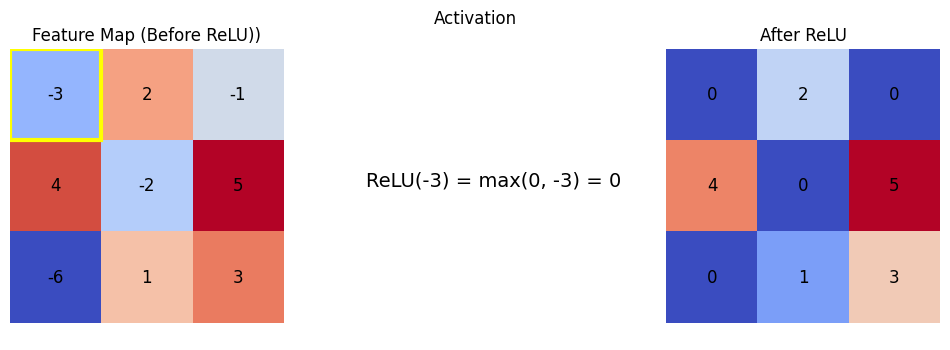

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from IPython.display import HTML

feature_map = np.array([
    [-3,  2, -1],
    [ 4, -2,  5],
    [-6,  1,  3]
])

relu_map = np.zeros_like(feature_map)

steps = []

for i in range(feature_map.shape[0]):
    for j in range(feature_map.shape[1]):
        val = feature_map[i, j]
        relu_val = max(0, val)
        steps.append((i, j, val, relu_val))

fig, axes = plt.subplots(1, 3, figsize=(12,4))

def draw_matrix(ax, matrix, title):
    ax.imshow(matrix, cmap='coolwarm')
    for r in range(matrix.shape[0]):
        for c in range(matrix.shape[1]):
            ax.text(c, r, str(matrix[r,c]),
                    ha='center', va='center', fontsize=12)
    ax.set_title(title)
    ax.axis('off')

def update(frame):
    for ax in axes:
        ax.clear()

    i, j, val, relu_val = steps[frame]

    # LEFT: Original feature map
    draw_matrix(axes[0], feature_map, "Feature Map (Before ReLU))")

    rect = Rectangle((j-0.5, i-0.5), 1, 1,
                     edgecolor='yellow', facecolor='none', linewidth=3)
    axes[0].add_patch(rect)

    # MIDDLE: Transformation
    axes[1].text(0.1, 0.5,
                 f"ReLU({val}) = max(0, {val}) = {relu_val}",
                 fontsize=14)
    axes[1].set_title("Activation")
    axes[1].axis('off')

    # RIGHT: Output building
    relu_map[i, j] = relu_val
    draw_matrix(axes[2], relu_map, "After ReLU")

ani = animation.FuncAnimation(
    fig, update,
    frames=len(steps),
    interval=800,
    repeat=False
)

HTML(ani.to_jshtml())

Pooling Layer

The pooling layer comes after the convolution and activation stages in many CNN architectures. Its main purpose is to reduce the spatial size of the feature maps, that is, to reduce their height and width while keeping the most useful information.

This reduction is important for three main reasons. First, it reduces the amount of computation required in the later layers. Second, it helps reduce overfitting by simplifying the representation. Third, it helps preserve the most important features while removing small unnecessary details.

There are two common types of pooling. The first is max pooling, which selects the largest value from a small region of the feature map. The second is average pooling, which computes the average value of that region. Among these two, max pooling is used more often because it keeps the strongest and most important feature response.

For example, consider a 2×2 region:
\begin{bmatrix}
1 & 2 \\
5 & 3
\end{bmatrix}


If we apply max pooling, the output is $5$ because $5$ is the largest value in that region.

In simple terms, the pooling layer makes the feature map smaller and easier to process, while still keeping the most important information needed for learning.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving MaxPooling.png to MaxPooling.png


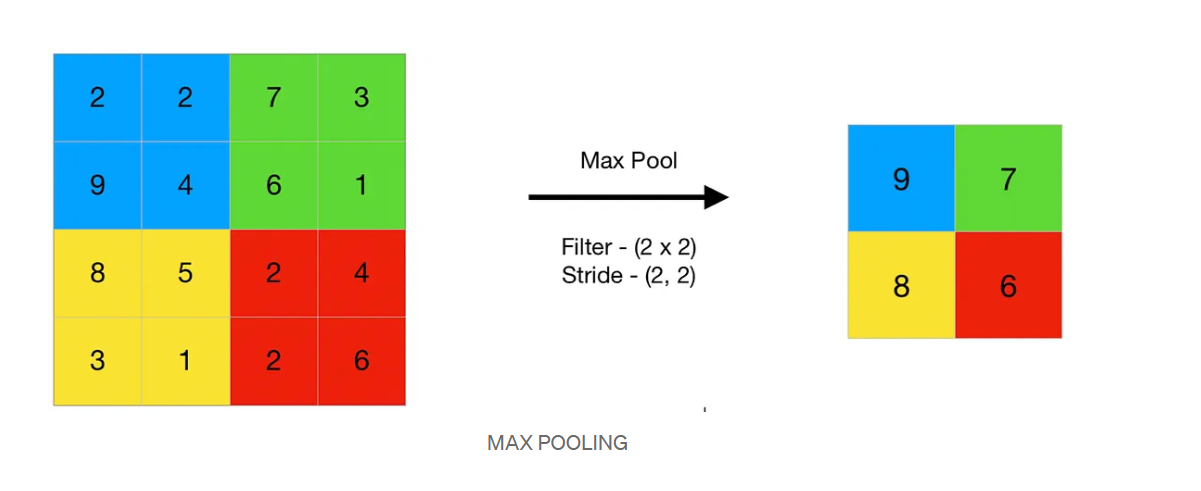

In [4]:
from IPython.display import Image, display

display(Image('MaxPooling.png'))

In [5]:
from google.colab import files
uploaded = files.upload()

Saving AveragePooling.png to AveragePooling.png


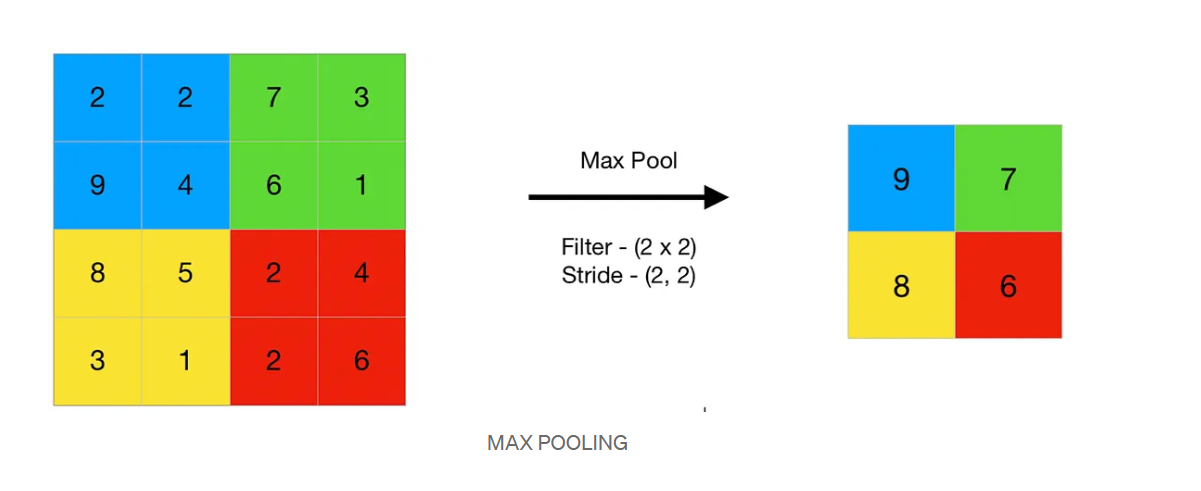

In [6]:
from IPython.display import Image, display

display(Image('MaxPooling.png'))

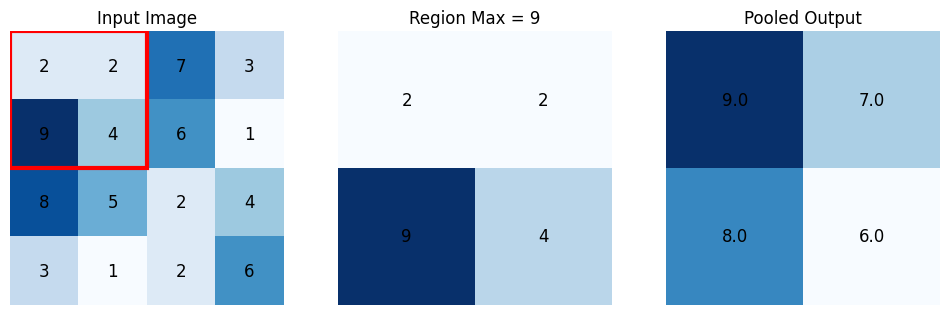

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from IPython.display import HTML

image = np.array([
    [2, 2, 7, 3],
    [9, 4, 6, 1],
    [8, 5, 2, 4],
    [3, 1, 2, 6]
])

pool_size = 2
stride = 2

h, w = image.shape

output_h = h // 2
output_w = w // 2
output = np.zeros((output_h, output_w))

steps = []
out_i = 0

for i in range(0, h, stride):
    out_j = 0
    for j in range(0, w, stride):

        region = image[i:i+pool_size, j:j+pool_size]
        max_val = np.max(region)

        steps.append((i, j, out_i, out_j, region, max_val))
        out_j += 1

    out_i += 1


fig, axes = plt.subplots(1, 3, figsize=(12,4))

def draw_matrix(ax, matrix, title):
    ax.imshow(matrix, cmap='Blues')

    for r in range(matrix.shape[0]):
        for c in range(matrix.shape[1]):
            ax.text(c, r, str(matrix[r,c]),
                    ha='center', va='center', fontsize=12)

    ax.set_title(title)
    ax.axis('off')


def update(frame):
    for ax in axes:
        ax.clear()

    i, j, oi, oj, region, max_val = steps[frame]

    # LEFT: Original Image
    draw_matrix(axes[0], image, "Input Image")

    rect = Rectangle((j-0.5, i-0.5),
                     pool_size, pool_size,
                     edgecolor='red',
                     facecolor='none',
                     linewidth=3)
    axes[0].add_patch(rect)

    # MIDDLE: Region
    draw_matrix(axes[1], region, f"Region Max = {max_val}")

    # RIGHT: Output building
    output[oi, oj] = max_val
    draw_matrix(axes[2], output, "Pooled Output")


ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(steps),
    interval=1200,
    repeat=False
)

HTML(ani.to_jshtml())


## Fully Connected Layer

After the convolutional and pooling layers have extracted the important features from the image, the next step is to use these features for decision-making. At this stage, the feature maps are flattened into a single long vector. Flattening means converting the two-dimensional or three-dimensional feature maps into a one-dimensional list of numbers so that they can be passed into the fully connected layer.

The fully connected layer is called fully connected because each neuron in this layer is connected to all the outputs from the previous layer. Its role is to combine the extracted features and use them to determine what class the image most likely belongs to. In other words, while the earlier layers learn visual features such as edges, shapes, and textures, the fully connected layer uses those learned features to perform the final classification.

For example, after learning useful patterns from an image, the fully connected layer may help the network decide whether the image belongs to one of the following classes: cat, dog, car, mango, or palm tree. Thus, this layer acts like the decision-making part of the CNN.

## Output Layer
The output layer is the final layer of the CNN. It gives the final prediction of the network. The number of neurons in the output layer usually depends on the number of classes in the problem. For example, if the task is to classify images into five classes, then the output layer will usually have five output values.
For multi-class classification, the most common activation function used in the output layer is Softmax. Softmax converts the raw output values of the network into probabilities, so that each value shows how likely the image belongs to a particular class. The Softmax function is written as

$$
P(y_i) = \frac{e^{z_i}}{\displaystyle \sum_{j=1}^{n} e^{z_j}}
$$

where $z_i​$ is the score for class iii, and the denominator is the sum of the exponential values of all class scores. This ensures that all the output probabilities are between 0 and 1, and that their total sum is 1.
For example, the output may be:

$$
\text{Cat: } 0.80 \\
\text{Dog: } 0.15 \\
\text{Bird: } 0.05 \
$$

This means the model believes there is an 80% chance the image is a cat, a 15% chance it is a dog, and a 5% chance it is a bird. Since the highest probability is for cat, the predicted class is Cat.
In simple terms, the fully connected layer prepares the final decision, and the output layer presents that decision clearly as the predicted class.

## CNN Architecture Flow

A typical CNN follows a step-by-step flow in which the image is gradually transformed from raw pixel values into a final prediction. A common structure is:

Input Image → Convolution → ReLU → Pooling → Convolution → ReLU → Pooling → Flatten → Fully Connected Layer → Output

This flow shows how the network learns from simple visual information and gradually builds toward a final classification decision.

In [10]:
from google.colab import files
uploaded = files.upload()

Saving cnn_architecture.png to cnn_architecture.png


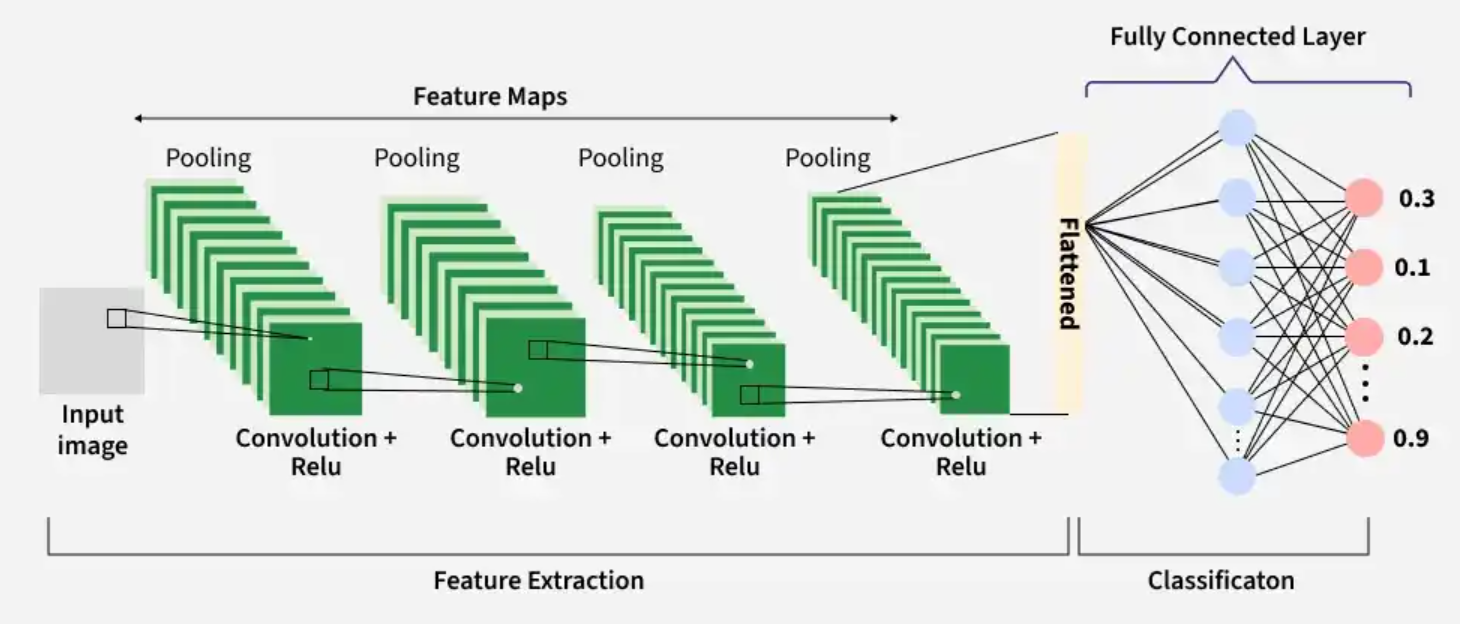

In [11]:
from IPython.display import Image, display

display(Image('cnn_architecture.png'))

First, the input image enters the network in the form of pixel values. These values may represent a grayscale image or a color image. The CNN begins by reading this image as structured data.

Next, the image passes through a convolutional layer, where filters scan small regions of the image to detect useful features such as edges, lines, corners, or textures. These filters help the network identify important local patterns.

After convolution, the output is passed through ReLU, an activation function that introduces non-linearity. This allows the network to learn more complex patterns rather than behaving like a simple linear model.

The result then goes through a pooling layer, which reduces the size of the feature maps. This makes the computation more efficient, reduces overfitting, and keeps the most important information.

As the data moves into deeper convolutional layers, the network begins to learn more abstract and meaningful features. Instead of only detecting simple edges or lines, deeper layers may learn parts of objects and eventually entire objects such as faces, leaves, fruits, vehicles, or other recognizable shapes.

After the final convolution and pooling stages, the learned feature maps are flattened into a one-dimensional vector. This vector is then passed to the fully connected layer, which combines all the extracted features and uses them to determine the class of the image.

Finally, the output layer produces the final prediction. It gives the class label or class probabilities, showing what the network believes the image represents.

In simple terms, the CNN architecture flow means that the image enters the network, filters detect features, activation adds learning power, pooling reduces size, deeper layers learn higher-level patterns, and the fully connected and output layers make the final classification.

## Hyperparameters in CNN
Hyperparameters in a CNN are design settings that control how the network processes an image and learns features. They are important because they affect the output size, computation cost, and overall performance of the model.

*Filter Size:** The filter size determines the size of the kernel used in convolution. Common sizes are $3×3$ and $5×5$. Smaller filters, especially $3×3$ , are often preferred because they use fewer parameters and still capture useful local features well.

*Number of Filters:** The number of filters determines how many different features a convolutional layer can learn. Common values include 16, 32, 64, and 128. More filters allow the network to learn more patterns, but they also increase computation and memory usage.

*Stride:** The stride controls how far the filter moves across the image each time. A stride of 1 means the filter moves one step, while a stride of 2 means it moves two steps. Smaller stride captures more detail, while larger stride reduces output size and computation.

*Padding:* Padding means adding zeros around the border of the image before convolution. This helps preserve edge information and control output size. In valid padding, no zeros are added, so the output becomes smaller. In same padding, zeros are added so that the output size remains close to the input size.

The main CNN hyperparameters are filter size, number of filters, stride, and padding, and each of them affects how the network learns and processes image features.

## How CNN Learns
A CNN learns through a process called training. During training, the network is shown many labeled images and gradually adjusts its internal weights so that it can make better predictions. The goal is to reduce the difference between the predicted output and the correct answer.

Step 1: Forward Propagation

In the first step, the input image is passed through the entire network. It goes through the convolutional layers, activation functions, pooling layers, and fully connected layers until the network produces an output prediction. For example, the CNN may look at an image and predict that it is a cat, dog, mango, or palm tree.

Step 2: Loss Calculation

After the prediction is made, the network compares it with the true label of the image. The difference between the predicted result and the correct result is measured using a loss function. The loss tells us how wrong the prediction is. For classification tasks, one of the most common loss functions is cross-entropy loss, because it measures how well the predicted probabilities match the true class.

Step 3: Backpropagation

Once the loss is computed, the network works backward to determine how each weight contributed to the error. This process is called backpropagation. In this step, the CNN calculates the gradients of the loss with respect to all the weights in the network. These gradients show the direction and amount by which the weights should change to reduce the error.

Step 4: Weight Update

After the gradients are found, the network updates its weights using an optimizer. The optimizer adjusts the weights in a way that helps reduce the loss and improve future predictions. Common optimizers include Gradient Descent, Stochastic Gradient Descent (SGD), and Adam.
This entire process is repeated many times over the training data. One complete pass through the full training dataset is called an epoch. As training continues over many epochs, the CNN gradually learns better features and improves its accuracy. In simple terms, the network learns by making predictions, measuring its error, correcting itself, and repeating this process until performance becomes better.

## Feature Learning in CNN
One of the greatest strengths of a CNN is that it can automatically learn features from images without needing a person to design those features by hand. This learning happens in a hierarchical manner, meaning the network starts with simple patterns and gradually builds them into more meaningful and complex representations.

In the early layers, the CNN learns very basic features such as edges, lines, and corners. These are the simplest visual elements in an image and serve as the foundation for recognizing more complex structures.

In the middle layers, the network combines these simple features to learn more meaningful patterns such as textures, shapes, and parts of objects. At this stage, the CNN begins to recognize structures that are more informative than single edges or lines.

In the deep layers, the CNN learns high-level and more complex features that are closely related to actual objects. These may include eyes, leaves, fruits, faces, or crowns of trees. In other words, the deeper layers capture more abstract and task-specific information.

This step-by-step learning of features, from simple to complex, is called hierarchical feature learning. It is one of the main reasons CNNs are so powerful and effective for image analysis, because the network can automatically discover the most useful visual patterns directly from the data.

## Common CNN Architectures

Over time, several CNN architectures have been developed, and each has made an important contribution to the progress of deep learning in computer vision. These architectures differ in depth, design, and purpose, but all of them helped improve how neural networks learn from images.

LeNet is one of the earliest CNN architectures. It was developed mainly for handwritten digit recognition, such as recognizing numbers in bank cheques or postal codes. Although it is small and simple compared to modern models, it introduced the basic idea of using convolution, pooling, and fully connected layers together.

AlexNet became very famous after winning the ImageNet competition in 2012. Its success showed that deep CNNs could achieve very high performance in image classification. AlexNet played a major role in bringing CNNs into widespread use and helped start the modern deep learning revolution in computer vision.

VGG is known for its simple and uniform design. It uses many small $ 3×3$ filters stacked one after another. This showed that deeper networks with small filters can learn powerful image features effectively. VGG is easy to understand and is often used for teaching and feature extraction.

ResNet, short for Residual Network, introduced the idea of residual connections or skip connections. These connections allow the network to train much deeper models without suffering badly from problems such as vanishing gradients. Because of this, ResNet made very deep CNNs more practical and effective.

EfficientNet was designed to improve performance while using computation more efficiently. It balances three important factors: network depth, network width, and image resolution. This makes it possible to achieve strong accuracy without making the model unnecessarily large.

*YOLO*, which stands for **You Only Look Once**, is mainly used for real-time object detection. Unlike models that only classify an image, YOLO can locate and identify multiple objects in the same image at high speed. This makes it very useful in applications such as surveillance, autonomous driving, agriculture, and video analysis.

LeNet introduced the early foundation of CNNs, AlexNet showed the power of deep CNNs, VGG emphasized simple deep structures, ResNet enabled very deep learning, EfficientNet improved efficiency, and now, **YOLO** made real-time object detection practical.

## YOLO

YOLO stands for You Only Look Once. It is one of the most popular models used for object detection in computer vision. Unlike ordinary image classification, which only tells us what is present in an image, YOLO performs two tasks at the same time. First, it detects the location of an object in the image. Second, it classifies the object by identifying what it is.

For example, instead of only saying, “there is a dog in this image,” YOLO can provide more useful information such as: dog at this location, car at this location, and person at this location. In this way, YOLO does not only recognize objects, but also shows where they appear in the image.

The name You Only Look Once comes from the fact that the model processes the image in a single pass and directly predicts both the object locations and their classes. Because of this one-step approach, YOLO is very fast compared with many older object detection methods. This speed makes it especially suitable for real-time detection tasks.

YOLO is widely used in many practical applications, including surveillance systems, self-driving vehicles, face and pedestrian detection, fruit and crop detection, tree crown detection, and medical or industrial inspection. Its ability to work quickly and accurately makes it valuable in situations where immediate results are needed.

One major reason YOLO is important is that it combines high speed, good accuracy, real-time performance, and the ability to detect multiple objects in a single image. This makes it both efficient and practical for real-world use.

The basic idea behind YOLO is simple. The model examines the image and predicts three main things: bounding boxes, which show where objects are located; object confidence, which shows how sure the model is that an object is present; and class labels, which identify the type of object detected.

YOLO is a deep learning model that can quickly locate and identify objects in an image or video, making it one of the most effective tools for real-time object detection. In this course, we’ll use YOLO to build a CNN as part of our guided project.

## How YOLO Works

When an image is given to YOLO, it passes through a deep neural network made mainly of convolutional layers. These layers act as feature extractors. In the early part of the network, simple features such as edges, lines, and textures are learned. In deeper parts, the network learns more meaningful patterns such as shapes, parts of objects, and full objects.

After extracting features from the image, YOLO does not stop at saying what is present. It also predicts the location of each object. So, for every relevant part of the image, the network tries to answer three main questions at once:

Is there an object here?
Where is the object located?
What class does the object belong to?

To do this, YOLO divides the image into regions and makes predictions from the learned feature maps. For each possible object, it predicts a bounding box, an objectness score, and class probabilities.

1. Bounding Box Prediction

A bounding box is the rectangle drawn around a detected object. YOLO predicts the box using four values: $(x,y,w,h)$

where: x and y represent the center of the box, w is the width, h is the height.

These values tell the model exactly where the object is in the image.

2. Objectness Score

YOLO also predicts an objectness score. This score tells how confident the model is that an object is actually present inside the predicted box. A high objectness score means the model strongly believes that the box contains an object. A low score means it is probably background.

3. Class Prediction

For each predicted box, YOLO also predicts the class of the object, such as: person, car, dog, mango, palm tree, etc.

This is done using class probabilities. The class with the highest score is usually chosen as the final label.

Internal Flow of YOLO

The internal working of YOLO can be understood in this order:

Input Image → Feature Extraction → Bounding Box Prediction → Objectness Prediction → Class Prediction → Final Detection.

This means the model first studies the image, learns important features, then predicts boxes, confidence, and classes, and finally returns the detected objects.

Feature Extraction Stage

The first part of YOLO is often called the backbone. This is the part responsible for extracting important visual features from the image. It works like a CNN by applying many convolution operations to transform the raw image into deep feature maps.

These feature maps contain rich information about: edges, textures, object parts, spatial arrangement. This stage is very important because the quality of the later predictions depends on how well the image features are learned.

Detection Stage

After feature extraction, YOLO uses a detection part, sometimes called the head, to make predictions. This part looks at the feature maps and outputs: box coordinates, confidence scores, and class scores.

In modern YOLO models, detection is often done at multiple scales. This helps the network detect:small objects, medium objects, and large objects

For example, a small fruit far away and a large vehicle close to the camera can both be detected because different feature map sizes are used.

Why YOLO Is Fast

YOLO is fast because it performs detection in one forward pass through the network. Older methods often worked in multiple stages, such as: propose object regions, classify each region, refine the boxes.

YOLO avoids this multi-step process. It predicts everything together in one network pass, which is why it can work in real time.

Non-Maximum Suppression (NMS)

After YOLO makes many predictions, several boxes may point to the same object. For example, the model may predict three overlapping boxes around one dog. To solve this, YOLO uses Non-Maximum Suppression (NMS).

NMS works by: keeping the box with the highest confidence score,
removing other overlapping boxes that are too similar, and repeating this process for the remaining predictions.

This helps produce one clean box per object instead of many duplicates.

Training Process

During training, YOLO learns by comparing its predictions with the true labeled boxes and classes in the dataset. It adjusts its weights so that over time it becomes better at:

$i).$ placing boxes correctly,
$ii).$ assigning the right class,
$iii).$ giving higher confidence to true objects,
$iv).$ giving lower confidence to background.

The loss function in YOLO usually combines different types of errors, including:

1. localization error, for wrong box position or size,
2. confidence error, for wrong objectness score,
3. classification error, for wrong class prediction.

The network then uses backpropagation and an optimizer such as SGD or Adam to improve its weights.

Simple Example

Suppose an image contains a dog and a car. Internally, YOLO processes the image and may produce predictions like this:

Box 1: dog, $\text confidence = 0.92$

Box 2: car, $\text confidence = 0.88$

Box 3: dog, $\text confidence = 0.60$, overlapping with Box 1.

Then NMS removes the weaker overlapping dog box and keeps the stronger one. The final result becomes:

* dog at this location
* car at this location

In Simple Terms, YOLO works internally by:

taking the whole image as input,
extracting features with convolutional layers,
predicting bounding boxes, object confidence, and class labels together,
removing repeated boxes,
returning the final detected objects.

So, unlike ordinary classification, YOLO does not just say what is in the image. It also shows where each object is, and it does this very quickly.

## YOLO Annotation Format

The YOLO annotation format is the standard way of writing object labels so that a YOLO model can learn from images. In object detection, each image usually has a corresponding text file with the same filename.

#### Example

```
image1.jpg
image1.txt
```

The `.txt` file contains the annotations for all objects present in that image.


#### Basic Format for Object Detection

In YOLO object detection, each line in the label file represents one object and is written in the following format:

```
class_id x_center y_center width height
```

These five values are separated by spaces.

#### Meaning of the Values

- **class_id**: the numerical label assigned to the object class  
- **x_center**: the x-coordinate of the center of the bounding box  
- **y_center**: the y-coordinate of the center of the bounding box  
- **width**: the width of the bounding box  
- **height**: the height of the bounding box  

A key point is that the last four values are **normalized**, not given in raw pixels. This means they are divided by the image width or height, so they usually fall between 0 and 1.

#### Example

A label file may contain:

```
0 0.50 0.40 0.30 0.20
1 0.70 0.65 0.15 0.25
```

This means:

- the first object belongs to class 0, with center at (0.50, 0.40), width 0.30, and height 0.20  
- the second object belongs to class 1, with center at (0.70, 0.65), width 0.15, and height 0.25  

If the class names are defined as:

```yaml
names:
  0: mango
  1: palm
```

then the image contains one mango and one palm.

#### Important Notes

- The coordinates are based on the **center** of the bounding box, not the top-left corner.  
- The coordinate and size values are **normalized**, so they are usually between 0 and 1.  
- Each object must be written on a **separate line**.  
- If an image contains no object, its label file may be empty or may not exist, depending on the dataset setup.  

#### Example Using Real Image Size

Suppose an image has:

```
width = 1000 pixels
height = 500 pixels
```

and an object has:

```
center x = 500
center y = 200
width = 300
height = 100
```

Then the YOLO annotation becomes:

```
0 0.5 0.4 0.3 0.2
```

because:

```
x_center = 500 / 1000 = 0.5
y_center = 200 / 500  = 0.4
width    = 300 / 1000 = 0.3
height   = 100 / 500  = 0.2
```

#### Common Folder Structure

A typical YOLO dataset is arranged as follows:

```
dataset/
├── images/
│   ├── train/
│   ├── val/
│   └── test/
├── labels/
│   ├── train/
│   ├── val/
│   └── test/
```

Each image should have a matching label file in the corresponding labels folder.

Example:

```
images/train/img001.jpg
labels/train/img001.txt
```

## Class Mapping in YAML

YOLO also uses a `.yaml` file to define the dataset path and class names:

```yaml
path: /content/dataset
train: images/train
val: images/val

names:
  0: mango
  1: palm
  2: other
```

This file tells YOLO what each class ID represents.

#### Other YOLO Annotation Variants

Besides object detection, YOLO can also be used for other tasks, and the annotation format changes slightly.

- **Segmentation**:
```
class_id x1 y1 x2 y2 x3 y3 ...
```

- **Pose Estimation**:
Includes bounding box information along with keypoints (e.g., body joints).

- **Oriented Bounding Boxes**:
Includes extra values to represent rotated boxes.


By way of summary, the standard YOLO annotation format for object detection is:

```
class_id x_center y_center width height
```

Here, the coordinates are normalized, and each line represents one object. This format is simple, compact, and widely used for training YOLO detection models.

## YOLO Versions

The YOLO family began with **YOLOv1** in 2015, which framed object detection as a **single regression problem**. In this approach, one network predicts bounding boxes and class probabilities directly from the full image in a single evaluation.

Over time, **“YOLO” evolved into a broader family name** rather than a strictly continuous line from a single research lab. Different versions have been developed and improved by various groups, each introducing new ideas, optimizations, and performance improvements.

In the current **Ultralytics ecosystem**:

- **YOLO11** is presented as the **stable and recommended choice** for most applications.  
- **YOLO26** is listed as the **latest model**, representing the newest advancements in the YOLO series.

#### Key Insight

YOLO has evolved from a single model into a **family of object detection architectures**, with each version improving speed, accuracy, and usability.

## YOLO Training with YOLO11

YOLO11 is one of the Ultralytics YOLO model families, and the official docs show that YOLO11 models support training, validation, inference, and export across multiple tasks. For object detection, the common pretrained model names include variants such as `yolo11n.pt`, `yolo11s.pt`, `yolo11m.pt`, `yolo11l.pt`, and `yolo11x.pt`.

To train YOLO11, the practical workflow is simple: prepare the dataset, create the YAML file, choose a pretrained YOLO11 model, start training, monitor validation results, and then save the best weights for inference or further fine-tuning. Ultralytics uses the same general CLI syntax:

```
yolo TASK MODE ARGS
```

and its Python API follows the same pattern through:

```python
model.train(...)
```

#### 1. Prepare the Dataset

For YOLO11 object detection, your dataset should contain images and matching label files in YOLO format. The dataset configuration is defined using a YAML file that points to the training and validation image folders and defines the class names.

A typical structure is:

```
dataset/
├── images/
│   ├── train/
│   └── val/
├── labels/
│   ├── train/
│   └── val/
```

Each image must have a corresponding `.txt` label file with the same filename in the matching labels folder.

#### 2. Create the Dataset YAML File

You then create a dataset YAML file such as `data.yaml`. This file tells YOLO11 where the data is and what the class IDs mean.

Example:

```yaml
path: /path/to/dataset
train: images/train
val: images/val

names:
  0: mango
  1: palm
  2: other
```

- `path`: dataset root  
- `train`, `val`: image folders  
- `names`: class ID mapping  

#### 3. Choose a YOLO11 Model

It is recommended to start from pretrained weights.

Available options:

- `yolo11n.pt` → small, fast  
- `yolo11s.pt` → slightly larger  
- `yolo11m.pt`, `yolo11l.pt`, `yolo11x.pt` → larger, more accurate  

#### 4. Start Training from the Command Line

Ultralytics CLI syntax:

```
yolo detect train model=yolo11n.pt data=data.yaml epochs=100 imgsz=640
```

Meaning:

- `detect` → object detection task  
- `train` → training mode  
- `model` → pretrained weights  
- `data` → dataset config  
- `epochs` → training iterations  
- `imgsz` → image size  

#### 5. Start Training in Python

```python
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
results = model.train(data="data.yaml", epochs=100, imgsz=640)
```

#### 6. What Happens During Training

During training:

- Images are loaded in batches  
- Predictions are made  
- Compared with ground truth  
- Loss is computed  
- Weights are updated  

Key hyperparameters include:
- batch size  
- learning rate  
- momentum  
- weight decay  

#### 7. Important Training Arguments

- `model`: pretrained `.pt` file  
- `data`: dataset YAML  
- `epochs`: number of training epochs  
- `imgsz`: image size  
- `batch`: batch size  
- `device`: CPU or GPU  
- `workers`: data loader workers  

Example:

```
yolo detect train model=yolo11s.pt data=data.yaml epochs=100 imgsz=640 batch=16 device=0
```

#### 8. Validation During and After Training

CLI:

```
yolo detect val model=runs/detect/train/weights/best.pt data=data.yaml
```

Python:

```python
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")
metrics = model.val(data="data.yaml")
```

#### 9. Using the Trained YOLO11 Model

After training, use the saved weights for inference.

Example:

```
yolo detect predict model=runs/detect/train/weights/best.pt source=path/to/image.jpg
```

## 10. Step-by-Step Summary

- collect images  
- annotate in YOLO format  
- organize `images/` and `labels/`  
- create `data.yaml`  
- choose pretrained model (e.g., `yolo11n.pt`)  
- run training  
- validate results  
- use `best.pt` for inference  

## Minimal Example

```
yolo detect train model=yolo11n.pt data=data.yaml epochs=100 imgsz=640
```

This is the simplest way to train YOLO11 on a custom dataset using the Ultralytics workflow.

## Practical Implementation
#### YOLO11 Training in Google Colab

#### Install Ultralytics

```python
!pip install -q ultralytics
```

#### Mount Google Drive

```python
from google.colab import drive
drive.mount('/content/drive')
```

#### Import Libraries

```python
from ultralytics import YOLO
import yaml, os
```

#### Define Dataset Path

```python
dataset_root = "/content/drive/MyDrive/yolo_dataset"
```

#### Create Dataset YAML File

```python
data = {
    "path": dataset_root,
    "train": "images/train",
    "val": "images/val",
    "names": {
        0: "mango",
        1: "palm",
        2: "other"
    }
}

yaml_path = "/content/data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)
```

---

#### Load Pretrained YOLO11 Model

```python
model = YOLO("yolo11n.pt")
```

#### Train the Model

```python
model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    project="/content/runs",
    name="yolo11_custom"
)
```

#### Validate the Model

```python
best_model = YOLO("/content/runs/yolo11_custom/weights/best.pt")
best_model.val(data=yaml_path)
```

#### Run Inference (Prediction)

```python
best_model.predict(
    source="/content/drive/MyDrive/test_image.jpg",
    save=True,
    conf=0.25
)
```

#### Equivalent CLI Commands

Ultralytics documents the CLI pattern as:

```
yolo TASK MODE ARGS
```
The same workflow can be written in CLI form.

#### Train

```bash
!yolo detect train model=yolo11n.pt data=/content/data.yaml epochs=100 imgsz=640 batch=16
```
#### Validate

```bash
!yolo detect val model=runs/detect/train/weights/best.pt data=/content/data.yaml
```
#### Predict

```bash
!yolo detect predict model=runs/detect/train/weights/best.pt source=/content/drive/MyDrive/test_image.jpg
```
#### Practical Tips
Start with **`yolo11n.pt`** because it is lighter and faster. Move to **`yolo11s.pt`** or **`yolo11m.pt`** for better performance  

YOLO11 is designed to be fast and efficient, so this progression helps balance **speed vs accuracy**.

#### Dataset Tips

If your dataset is small, start with fewer classes and ensure labels are clean and accurate. Training quality depends heavily on: Correct annotations and Proper train/validation split.  

This is why Ultralytics emphasizes:dataset structure and YAML configuration  

## Roboflow

Roboflow is a web-based computer vision platform used to manage image datasets, annotate images, preprocess and augment data, create dataset versions, and export datasets for model training. Roboflow’s annotation tool supports tasks such as object detection, instance segmentation, keypoint detection, and classification. Its workflow is built around generating a **dataset version**, which is a frozen snapshot of your data and settings at a specific point in time.

#### Roboflow in YOLO11 Workflow

In a YOLO11 workflow, Roboflow is most useful at the **data preparation stage**.

A common pipeline is Upload images, Annotate objects, Choose preprocessing and augmentation settings, Generate a dataset version, and Export or download the dataset  

Roboflow provides tools for labeling, preprocessing, and augmentation, while YOLO11 uses the prepared dataset for training.

#### Dataset Versioning in Roboflow

A key concept in Roboflow is **dataset versioning**.

After labeling your data:

1. Go to the **Versions** page  
2. Choose:
   - Train/validation/test split  
   - Preprocessing options  
   - Augmentation settings  
3. Click **Generate New Version**

You must create a dataset version before exporting or downloading it.

#### Exporting for YOLO11

After generating a version:

- Export the dataset in a YOLO-compatible format  
- Use it for training in Colab or locally  

Roboflow’s YOLO11 guides recommend:

- First train **without augmentation** (baseline)  
- Then experiment with augmented versions  

#### Roboflow vs YOLO11

- **Roboflow** → Data preparation (annotation, cleaning, versioning)  
- **YOLO11** → Model training and prediction  

Roboflow is not the model; it is a **data preparation platform**.

#### Practical Roboflow → YOLO11 Workflow

1. Upload images to Roboflow  
2. Annotate objects  
3. Generate a dataset version (with optional preprocessing/augmentation)  
4. Export or download the dataset  
5. Train YOLO11 using the exported data  

#### Key Insight

Roboflow helps you create **clean, organized, versioned datasets**, while YOLO11 uses that data to learn and detect objects effectively.

### CNN Evaluation Metrics

CNN evaluation metrics are the measures used to check how well a Convolutional Neural Network performs on unseen data. The exact metric depends on the task. For image classification, the most common metrics are accuracy, precision, recall, F1-score, confusion matrix, and loss. For object detection and segmentation, other metrics such as IoU and mAP are also important.

## 1. Accuracy

Accuracy measures the proportion of correctly classified samples out of all samples.

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

Where:  
    &nbsp;&nbsp;&nbsp;&nbsp;TP = True Positives  
    &nbsp;&nbsp;&nbsp;&nbsp;TN = True Negatives  
    &nbsp;&nbsp;&nbsp;&nbsp;FP = False Positives  
    &nbsp;&nbsp;&nbsp;&nbsp;FN = False Negatives  

Accuracy is useful when classes are balanced, but can be misleading for imbalanced datasets.

#### 2. Precision

Precision shows how many of the samples predicted as positive are actually positive.

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

A high precision means fewer false positives.

#### 3. Recall

Recall (sensitivity) measures how many actual positive samples are correctly identified.

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

A high recall means fewer missed positive cases.

#### 4. F1-Score

The F1-score is the harmonic mean of precision and recall.

$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

Useful for imbalanced datasets.

#### 5. Specificity

Specificity measures how well the model identifies negative samples.

$$
\text{Specificity} = \frac{TN}{TN + FP}
$$

## 6. Confusion Matrix

A confusion matrix summarizes classification results:

- True Positive (TP): correctly predicted positives  
- True Negative (TN): correctly predicted negatives  
- False Positive (FP): incorrect positive prediction  
- False Negative (FN): incorrect negative prediction  

It helps identify the types of errors made by the model.

#### 7. Loss

Loss measures how far predictions are from true labels.

- Goal: minimize loss during training  
- Common loss: **cross-entropy loss**

Lower loss generally indicates better learning, but should be evaluated alongside other metrics.

#### 8. ROC Curve and AUC

- ROC curve shows True Positive Rate vs False Positive Rate  
- AUC summarizes the ROC curve  

```
AUC = 1   → perfect model  
AUC = 0.5 → random guessing  
```

Higher AUC indicates better class separation.

#### 9. Top-1 and Top-5 Accuracy

Used in multi-class classification:

**Top-1 Accuracy**: correct class is highest prediction  
**Top-5 Accuracy**: correct class is within top 5 predictions  

Common in large-scale classification tasks.

## Metrics for Detection and Segmentation

#### 10. Intersection over Union (IoU)

IoU measures overlap between predicted and true regions.

$$
\text{IoU} = \frac{\text{Area of Overlap}}{\text{Area of Union}}
$$

Higher IoU means better localization.

#### 11. mAP (Mean Average Precision)

mAP evaluates detection performance across classes and IoU thresholds.

- Higher mAP → better detection performance  

# Summary

## Classification Metrics

- Accuracy → overall correctness  
- Precision → correctness of positive predictions  
- Recall → ability to find positives  
- F1-score → balance between precision and recall  
- Confusion matrix → detailed error analysis  
- Loss → training performance  
- ROC-AUC → class separation quality  

## Detection Metrics

- IoU → overlap quality  
- mAP → overall detection performance  

#### Key Insight

- For **balanced datasets** → accuracy may be sufficient  
- For **imbalanced datasets** → precision, recall, and F1-score are more reliable  

#### YOLO evaluation metrics

YOLO evaluation metrics are used to measure how well the model detects objects, places bounding boxes correctly, and assigns the right class labels. The main metrics commonly reported during validation are Precision, Recall, mAP50, and mAP50-95.


**IoU (Intersection over Union)** measures the overlap between the predicted bounding box and the ground-truth bounding box. A higher IoU means the predicted box matches the true object location more closely.


**Precision** shows how many predicted detections are actually correct. It reflects how well the model avoids false positives.


**Recall** shows how many real objects are successfully detected. It reflects how well the model avoids false negatives.


**Average Precision (AP)** summarizes the precision-recall performance for one class, while mean Average Precision (mAP) gives the average AP across all classes.


Two important forms of mAP are commonly used. mAP50 measures performance at an IoU threshold of 0.50 and is a less strict metric. mAP50-95 averages performance across IoU thresholds from 0.50 to 0.95 and gives a stricter and more complete evaluation.


The *F1 score* is the harmonic mean of precision and recall, so it is useful when both false positives and false negatives matter.


A *confusion matrix* helps show which classes the model predicts correctly and which classes it confuses. Speed metrics measure how fast the model runs, including preprocessing, inference, and post-processing time, which is important for real-time applications.


YOLO also reports class-wise metrics, showing performance for each class separately. This helps identify classes the model detects well and those it struggles with.


In summary, the most important YOLO evaluation metrics are IoU, Precision, Recall, AP, mAP50, mAP50-95, F1 score, confusion matrix, and speed. Among these, mAP50 and mAP50-95 are the main overall performance measures, while precision and recall explain the types of errors the model makes.

## Freezing layers in YOLO11

In YOLO11 training, freezing layers means keeping some pretrained layers unchanged while training the rest of the model. Ultralytics exposes this through the freeze training argument, which can freeze either the first N layers or specific layers by index. This is mainly used for transfer learning and fine-tuning.

#### What freezing does

When a layer is frozen, its weights are not updated during backpropagation. In practice, this means the early feature-extraction part of the model can stay fixed while the later layers adapt to your new dataset. Ultralytics notes that freezing reduces the number of trainable parameters and is useful for fine-tuning.

#### Why use it

Freezing is helpful when you are training YOLO11 on a small or specialized dataset, because the pretrained backbone already knows general visual features such as edges, textures, and shapes. A common strategy is to freeze the backbone first, let the detection head adapt, and then optionally unfreeze everything later for full fine-tuning. Ultralytics specifically recommends this pattern in its custom trainer guide.

#### How to use freeze

Ultralytics supports two main forms:

- `freeze=10` freezes the first 10 layers.  
- `freeze=[0, 1, 2, 3]` freezes specific layers by index.  

A simple YOLO11 CLI example is:

```bash
yolo detect train model=yolo11n.pt data=data.yaml epochs=100 freeze=10
```

A Python example is:

```python
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
model.train(data="data.yaml", epochs=100, freeze=10)
```

The same training argument is documented in Ultralytics’ general training/configuration docs and applies to current Ultralytics YOLO training workflows.

#### What value should you choose?

A practical starting point is:

- No freezing if you have a large, diverse dataset.  
- Freeze a few early layers if your dataset is small but similar to common object datasets.  
- Freeze more of the backbone if you want the head to adapt first and avoid over-changing the pretrained features early in training.  

Ultralytics’ custom trainer guide gives `freeze=10` as the example for freezing the first 10 layers, noting this is typically the backbone in YOLO architectures. The exact best value can vary by model and architecture, so it is something to test experimentally.

#### Gradual unfreezing

Ultralytics also documents a callback-based approach where you freeze layers at the start and then unfreeze them after a chosen number of epochs. Their example uses an `on_train_epoch_start` callback to unfreeze all parameters after a fixed number of epochs. This is useful when you want a staged fine-tuning schedule.

#### BatchNorm caution

Ultralytics also provides a callback example for putting frozen BatchNorm layers into evaluation mode so their running statistics do not keep changing. This is an advanced option, but it can matter when you are deliberately freezing part of the network.
